# Parameters in the Synthetic Copula Model
This method follows the developments by Widén and Munkhammar [1] on Gaussian copula-based downscaling methods. The parameters used to model the irradiance are given on p3173 of the paper.

[1] Widén, J. and Munkhammar, J., "Spatio-Temporal Downscaling of Hourly Solar irradiance Data Using Gaussian Copulas," 2019 IEEE 46th Photovoltaic Specialists Conference (PVSC), Chicago, IL, USA, 2019, pp. 3172-3178, doi: https://dx.doi.org/10.1109/PVSC40753.2019.8980922.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from solarspatialtools.synthirrad.copula import _sigmoid, _exponential_decay_parameter, _process_params, DEFAULT_PARAMS

## Equations for parameters

In all cases, a subscript of 1 indicates the cloudy component, and a subscript of 2 indicates the clear component. The parameters are all functions of the mean CSI, which is denoted as $\overline{\kappa}$.

### Weights
Equations 10 from the paper  - `params['comp']` in the code correspond to `['p1', 'p2', 'p3']`
- $w_2(\overline{\kappa}) = p_1 * S(\overline{\kappa}, p_2, p_3)$
- $w_1(\overline{\kappa}) = 1 - w_2(\overline{\kappa})$

### Means
Equations 12 and 13 from the paper - `params['mean']` in the code correspond to `['m1', 'm2', 'm3']`
- $\mu_1(\overline{\kappa}) = {m}_1 * \overline{\kappa} * w_1(\overline{\kappa}) + {m}_2* w_2(\overline{\kappa}) * ( \overline{\kappa} - {m}_3 )$
- $\mu_2(\overline{\kappa}) = \frac{\overline{\kappa} - w_1(\overline{\kappa}) * \mu_1(\overline{\kappa})}{w_2(\overline{\kappa})}$
   - based on the notion that $\overline{\kappa} = w_1 * \mu_1 + w_2 * \mu_2$

### Standard Deviations
Equations 14 and 15 from the paper - `params['sdevClear']` contains `["s'1", "s'2", "s'3"]` and `params['sdevCloud']` contains `['s1', 's2', 's3']`
- $\sigma_1(\overline{\kappa}) = s_1 * S(\overline{\kappa}, s_2, s_3)$ using the values in `params['sdevCloud']` in the code
- $\sigma_2(\overline{\kappa}) = s'_1 * (1 - S(\overline{\kappa}, s'_2, s'_3))$ using the values in `params['sdevClear']` in the code

(0.0, 1.5)

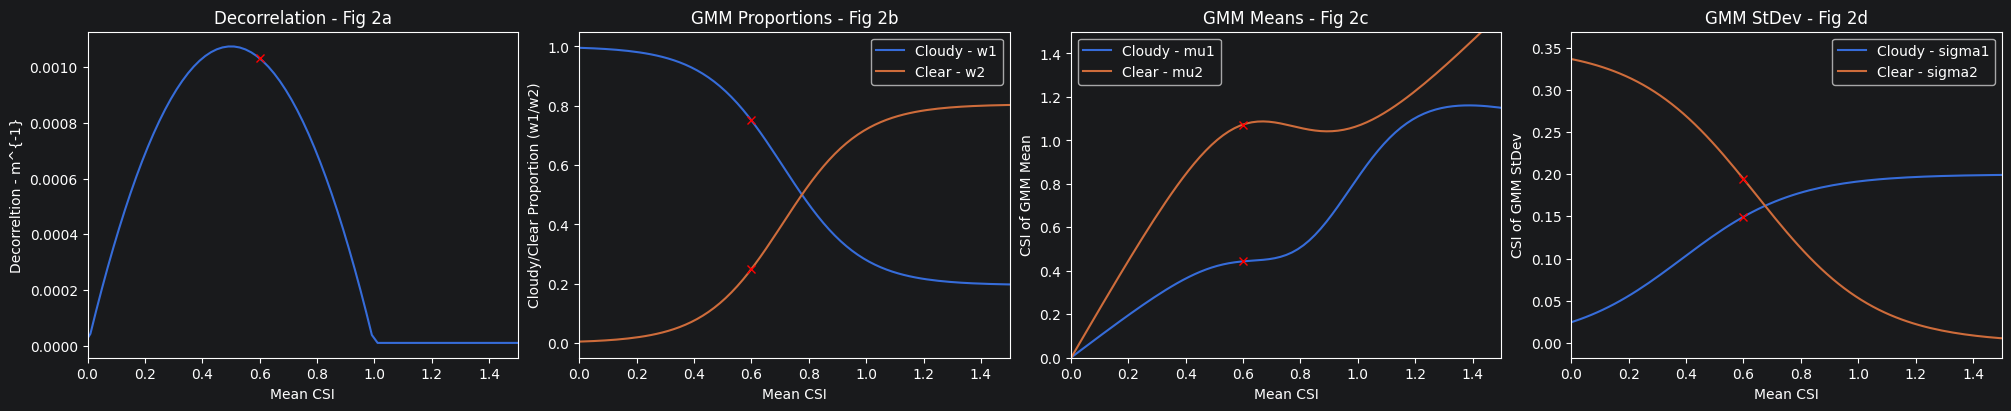

In [23]:
params = DEFAULT_PARAMS.copy()
x_axis = np.linspace(-10, 10, 1000)
meanCSI = 0.6

mu, w, variance, k = _process_params(x_axis, params)
mui, wi, variancei, ki = _process_params(meanCSI, params)

sigma = [np.sqrt(variance[0]), np.sqrt(variance[1])]
sigmai = [np.sqrt(variancei[0]), np.sqrt(variancei[1])]

fig, axs = plt.subplots(1, 4, figsize=(20, 4), constrained_layout=True)

# 1) Decorrelation (Fig 2a)
axs[0].plot(x_axis, k)
axs[0].plot(meanCSI, ki, 'rx')
axs[0].set_title('Decorrelation - Fig 2a')
axs[0].set_ylabel('Decorreltion - m^{-1}')
axs[0].set_xlabel('Mean CSI')
axs[0].set_xlim([0, 1.5])

# 2) Weights (Fig 2b)
axs[1].plot(x_axis, w[0])
axs[1].plot(x_axis, w[1])
axs[1].plot(meanCSI, wi[0], 'rx')
axs[1].plot(meanCSI, wi[1], 'rx')
axs[1].set_title('GMM Proportions - Fig 2b')
axs[1].legend(['Cloudy - w1', 'Clear - w2'])
axs[1].set_ylabel('Cloudy/Clear Proportion (w1/w2)')
axs[1].set_xlabel('Mean CSI')
axs[1].set_xlim([0, 1.5])

# 3) Means (Fig 2c)
axs[2].plot(x_axis, mu[0])
axs[2].plot(x_axis, mu[1])
axs[2].plot(meanCSI, mui[0], 'rx')
axs[2].plot(meanCSI, mui[1], 'rx')
axs[2].set_title('GMM Means - Fig 2c')
axs[2].legend(['Cloudy - mu1', 'Clear - mu2'])
axs[2].set_ylabel('CSI of GMM Mean')
axs[2].set_xlabel('Mean CSI')
axs[2].set_xlim([0, 1.5])
axs[2].set_ylim([0, 1.5])

# 3) Standard Deviation (Fig 2c)
axs[3].plot(x_axis, sigma[0])
axs[3].plot(x_axis, sigma[1])
axs[3].plot(meanCSI, sigmai[0], 'rx')
axs[3].plot(meanCSI, sigmai[1], 'rx')
axs[3].set_title('GMM StDev - Fig 2d')
axs[3].legend(['Cloudy - sigma1', 'Clear - sigma2'])
axs[3].set_ylabel('CSI of GMM StDev')
axs[3].set_xlabel('Mean CSI')
axs[3].set_xlim([0, 1.5])
